# Experimento Federado Semântico IoT/GenAI 6G

Neste laboratório em Jupyter Notebook, simulamos uma arquitetura de comunicação Edge via redes semânticas.

## 📘 Módulo 1: A Fundação Edge (Setup do Testbed)
Aqui instanciamos o cérebro PyTorch e subimos os contêineres Docker para emular nós GenAI independentes da nuvem.

In [3]:
# Célula 1 — Setup
import json, subprocess, time
from pathlib import Path
import requests

try:
    import pandas as pd; HAS_PANDAS = True
except ImportError:
    HAS_PANDAS = False; print('[aviso] pandas ausente')

try:
    import matplotlib.pyplot as plt, matplotlib, numpy as np
    HAS_MATPLOTLIB = True
    print(f'[ok] matplotlib {matplotlib.__version__}')
except Exception:
    HAS_MATPLOTLIB = False; print('[aviso] matplotlib ausente')

ML_SERVICE  = 'http://localhost:8000'
FL_SERVER   = 'http://localhost:8100'
SHARED_ROOT = Path('shared_data')
RESULTS_DIR = SHARED_ROOT / 'resultados' / 'notebook_monitor'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════
#  CONFIGURAÇÃO CENTRAL
# ════════════════════════════════════════════════════════
DATASET  = 'cifar10'    # mnist | fashion | cifar10
MODEL    = 'cnn_vae'
CLIENTS  = 3
ROUNDS   = 3
EPOCHS   = 3
SEED     = 42
AWGN_CFG = {'enabled': True, 'snr_db': 15}
MASK_CFG = {'enabled': True, 'drop_rate': 0.1, 'fill_value': 0.0}
LATENT_DIM = 32   # Utilizado nas etapas Manuais (Células 4 e 5)

# ════════════════════════════════════════════════════════

_BYTES_BRUTOS  = {'mnist': 3136, 'fashion': 3136, 'cifar10': 12288}
_BYTES_LATENTE = 32
print(f'[ok] {DATASET} | {MODEL} | {CLIENTS} clientes | {ROUNDS} rounds')
print(f'     Reducao teor.: {(1 - _BYTES_LATENTE/_BYTES_BRUTOS[DATASET])*100:.1f}%')

[ok] matplotlib 3.10.8
[ok] cifar10 | cnn_vae | 3 clientes | 3 rounds
     Reducao teor.: 99.7%


In [2]:
# Célula 2 — Subir containers Docker
import json, shutil, subprocess, time
from pathlib import Path
import requests

SHARED_ROOT = Path('shared_data')
for pasta in [SHARED_ROOT / 'fl-weights', SHARED_ROOT / 'resultados']:
    if pasta.exists(): shutil.rmtree(pasta); print(f'[setup] limpo: {pasta}')
for d in [SHARED_ROOT/'ml-data'/'datasets', SHARED_ROOT/'ml-data'/'runs',
          SHARED_ROOT/'ml-data'/'logs', SHARED_ROOT/'fl-weights',
          SHARED_ROOT/'resultados'/'notebook_monitor']:
    d.mkdir(parents=True, exist_ok=True)

print('[setup] Subindo containers...')
res = subprocess.run(['docker', 'compose', 'up', '-d', '--build'], capture_output=True, text=True)
if res.returncode != 0: print('ERRO:', res.stderr[-2000:]); raise RuntimeError('docker compose falhou')
print(f'[setup] OK')
time.sleep(8)
for nome, porta in [('ml-service', 8000), ('fl-server', 8100)]:
    ok = False
    for _ in range(20):
        try:
            if requests.get(f'http://localhost:{porta}/health', timeout=3).ok: ok = True; break
        except: pass
        time.sleep(2)
    print(f'[setup] {nome}: {"OK" if ok else "NAO RESPONDEU"}')
    if not ok: raise RuntimeError(f'{nome} nao respondeu')
print('[setup] Todos os containers prontos!')

[setup] limpo: shared_data\fl-weights
[setup] limpo: shared_data\resultados
[setup] Subindo containers...
[setup] OK
[setup] ml-service: OK
[setup] fl-server: OK
[setup] Todos os containers prontos!


In [8]:
# Célula 3 — Baixar datasets dentro do container
import time, requests
ML_SERVICE = 'http://localhost:8000'
DATASETS_A_BAIXAR = ['mnist', 'fashion', 'cifar10']
print(f'[datasets] Solicitando: {DATASETS_A_BAIXAR}')
r = requests.post(f'{ML_SERVICE}/data/prepare', json={'datasets': DATASETS_A_BAIXAR}, timeout=10)
print(f'[datasets] {r.json()}')
t0, ultimo = time.time(), None
while True:
    try: st = requests.get(f'{ML_SERVICE}/data/prepare/status', timeout=5).json()
    except: time.sleep(3); continue
    if st.get('current') != ultimo and st.get('current'):
        print(f'[datasets] Baixando {st["current"].upper()}...'); ultimo = st['current']
    if not st.get('running'):
        print(f'[datasets] Prontos: {st.get("done")}'); break
    if time.time()-t0 > 600: print('TIMEOUT'); break
    time.sleep(3)
print('[datasets] Pronto!')

[datasets] Solicitando: ['mnist', 'fashion', 'cifar10']
[datasets] {'status': 'started', 'datasets': ['mnist', 'fashion', 'cifar10']}
[datasets] Baixando MNIST...
[datasets] Baixando CIFAR10...
[datasets] Prontos: ['mnist', 'fashion', 'cifar10']
[datasets] Pronto!


---
## 🧠 Módulo 2: Os Dois Cérebros Semânticos (Treinamento Paralelo)

*A Comunicação Semântica exige dois agentes: A Antena Compressora (O Encoder Rádio Base) e o Sensor Decodificador (O Juiz Classificador).* Nossa inteligência artificial deve agora construir as lógicas matemáticas de transmissão para ruídos complexos.


In [ ]:
# Célula 4 — Treinar Autoencoder via FL com monitoramento em tempo real
import json, time
from pathlib import Path
import requests

try: DATASET; MODEL; CLIENTS; ROUNDS; EPOCHS; SEED; AWGN_CFG; MASK_CFG
except NameError:
    DATASET='mnist'; MODEL='cnn_vae'; CLIENTS=3; ROUNDS=5; EPOCHS=5; SEED=42
    AWGN_CFG={'enabled':True,'snr_db':15}; MASK_CFG={'enabled':True,'drop_rate':0.1,'fill_value':0.0}

ML_SERVICE='http://localhost:8000'; FL_SERVER='http://localhost:8100'
LOGS_DIR=Path('shared_data/ml-data/logs'); TIMEOUT=1800; MAX_FALHAS=10
KEYWORDS=('round','ep ','epoch','loss','fedavg','submit','shard','done','error','aggregat','client','training','batch','lr=')

def _novos(path, offset):
    if not path.exists(): return '', offset
    try: t=path.read_text(encoding='utf-8',errors='replace')
    except: return '', offset
    return t[offset:], len(t)

def _barra(a,t,w=30):
    p=min(a/max(t,1),1.0); c=int(p*w)
    return chr(9608)*c+chr(9617)*(w-c)

payload={'dataset':DATASET,'model':MODEL,'clients':CLIENTS,'epochs':EPOCHS, 'latent_dim':LATENT_DIM,
         'rounds':ROUNDS,'seed':SEED,'compression_mode':'baseline',
         'compression_bits':8,'awgn':AWGN_CFG,'masking':MASK_CFG}
print(f'[treino] {DATASET}/{MODEL} | {CLIENTS} clientes | {ROUNDS}x{EPOCHS}')
st=requests.post(f'{ML_SERVICE}/training/start',json=payload,timeout=15).json()
print(f'[treino] -> {st.get("status")}')
time.sleep(5)

offs={'server':0}; [offs.update({f'client-{i}':0}) for i in range(1,CLIENTS+1)]
t0=time.time(); falhas=0; ur=-1; ue=''
print(''+'='*65+f'MONITORAMENTO — {DATASET.upper()}'+'='*65)

while True:
    elapsed=int(time.time()-t0)
    if elapsed>TIMEOUT: print('TIMEOUT'); break
    try: ml=requests.get(f'{ML_SERVICE}/training/status',timeout=5).json(); falhas=0
    except:
        falhas+=1
        if falhas>=MAX_FALHAS: print('Containers nao respondem.'); break
        time.sleep(3); continue
    try:
        s=requests.get(f'{FL_SERVER}/training/status',timeout=5).json()
        estado=s.get('state','?'); rnd=int(s.get('current_round') or 0)
        tot=int(s.get('total_rounds') or ROUNDS); sub=s.get('submitted_clients',[])
        exp=int(s.get('expected_clients') or CLIENTS); hist=s.get('history',[])
    except: estado='?'; rnd=0; tot=ROUNDS; sub=[]; exp=CLIENTS; hist=[]
    if rnd!=ur or estado!=ue:
        barra=_barra(rnd,tot); pct=rnd/max(tot,1)*100
        sub_s=', '.join(str(x) for x in sorted(sub)) if sub else 'nenhum'
        print(f'+-- ROUND [{barra}] {rnd}/{tot} ({pct:.0f}%) [{elapsed}s] {estado}')
        print(f'  |   Submetidos: [{sub_s}] / {exp}')
        if hist: h=hist[-1]; print(f'  |   Round {h.get("epoch","?"):>2}: loss={h.get("loss",0):.5f}')
        print('  +'+'-'*62); ur=rnd; ue=estado
    for i in range(1,CLIENTS+1):
        k=f'client-{i}'; nv,offs[k]=_novos(LOGS_DIR/f'training_{k}.log',offs[k])
        for ln in nv.strip().split(''):
            if ln.strip() and any(w in ln.lower() for w in KEYWORDS): print(f'  [client-{i}] {ln.strip()}')
    nv_s,offs['server']=_novos(LOGS_DIR/'training_server.log',offs['server'])
    for ln in nv_s.strip().split(''):
        if ln.strip() and any(w in ln.lower() for w in KEYWORDS): print(f'  [server  ] {ln.strip()}')
    if not ml.get('running',False):
        try:
            res=requests.get(f'{ML_SERVICE}/results/latest',timeout=10).json()
            fl=res.get('final_loss','?'); hf=res.get('history',[])
            print(''+'='*65)
            print(f'  TREINO CONCLUIDO: {elapsed//60}min {elapsed%60}s | loss={fl}')
            if hf:
                print(f'  {"Round":>6} | {"Loss":>10} | {"Bytes Cli":>12} | {"Bytes Srv":>12}')
                print('  '+'-'*48)
                for h in hf:
                    print(f'  {str(h.get("epoch","?")):>6} | {float(h.get("loss",0)):>10.5f} | '
                          f'{int(h.get("bytes_clients",0) or 0):>10,} B | {int(h.get("bytes_global",0) or 0):>10,} B')
            print('='*65)
            Path('shared_data/resultados/notebook_monitor').mkdir(parents=True,exist_ok=True)
            Path('shared_data/resultados/notebook_monitor/treino_ref.json').write_text(
                json.dumps({'dataset':DATASET,'model':MODEL,'final_loss':fl},indent=2),encoding='utf-8')
            print('[treino] Pronto! Execute a celula 4.5.')
        except Exception as exc: print(f'Erro: {exc}')
        break
    time.sleep(4)

In [ ]:
# Célula 5 – Treinar Classificador Juiz
# Necessário para a métrica de Queda Semântica. Só precisa rodar UMA VEZ por dataset.
import time, requests

TREINAR_TODOS = True  # Mude para True para treinar os 3 de uma vez
alvos = ['mnist', 'fashion', 'cifar10'] if TREINAR_TODOS else [DATASET]
ML_SERVICE = 'http://localhost:8000'

# Configurações Dedicadas por Nível de Dificuldade do Dataset
CONFIG_TREINO = {
    'mnist':   {'epochs': 4,  'samples': 5000},   # Muito simples, treina ultra rápido
    'fashion': {'epochs': 8,  'samples': 12000},  # Médio, roupas variam em textura
    'cifar10': {'epochs': 20, 'samples': 25000}   # Complexo, requer mergulho profundo pros canais RGB
}

print("===========================================================")
print(f" Iniciando a Escola de Juízes Semânticos API ")
print("===========================================================")
print(f"Fila de Treinamento: {alvos}\n")

for DS in alvos:
    DS_safe = DS.lower().strip()
    cfg = CONFIG_TREINO.get(DS_safe, {'epochs': 5, 'samples': 3000})
    
    print(f"\n▶ [{DS_safe.upper()}] Acordando a API do Container...")
    print(f"  [PARÂMETROS] -> {cfg['epochs']} Épocas | {cfg['samples']} Imagens no Batch")
    try:
        # Inicia o treino no backend em background
        start = requests.post(f'{ML_SERVICE}/classifier/train-quick',
                              json={'dataset': DS_safe, 'epochs': cfg['epochs'], 'samples': cfg['samples'], 'seed': 42}, 
                              timeout=10)
        
        if start.status_code not in [200, 202]:
            print(f"  [ERRO DA API] O servidor devolveu Erro {start.status_code}: {start.text}")
            continue
            
        print(f"  [STATUS] Pedido Aceito. Monitorando o progresso...")
        
        t0 = time.time()
        ultimo_ep = -1
        while True:
            try: 
                st = requests.get(f'{ML_SERVICE}/classifier/train-quick/status', timeout=5).json()
            except:
                time.sleep(3)
                continue
            
            ep = st.get('epoch', 0)
            tot = st.get('total_epochs', cfg['epochs'])
            elapsed = int(time.time() - t0)
            
            if ep != ultimo_ep and ep > 0:
                print(f'  ✓ Epoch {ep}/{tot} ({ep/max(tot,1)*100:.0f}%) concluída [{elapsed}s]')
                ultimo_ep = ep
                
            if not st.get('running'):
                if st.get('error'):
                    print(f'  [ERRO NO TREINO]: {st["error"]}')
                elif st.get('done'):
                    acc = st.get('accuracy', 0)
                    print(f'  ★ MERGULHO CONCLUÍDO em {elapsed}s | Acurácia Forte: {acc*100:.1f}%')
                else:
                    print(f'  [AVISO] Status de execução parou misteriosamente! Verifique os logs do docker.')
                break
                
            if elapsed > 7200: # 1h de timeout pros complexos
                print('  [TIMEOUT] Tempo estourou (2 Horas de espera).')
                break
            time.sleep(4)
            
    except Exception as e:
        print(f"  [FALHA DE COMUNICAÇÃO HTTP]: {e}")

print("\n✓ Redes Julgadoras Profundas finalizadas! Pule para a Célula de Benchmark.")


 Iniciando a Escola de Juízes Semânticos API 
Fila de Treinamento: ['mnist', 'fashion', 'cifar10']


▶ [MNIST] Acordando a API do Container...
  [PARÂMETROS] -> 4 Épocas | 5000 Imagens no Batch
  [STATUS] Pedido Aceito. Monitorando o progresso...
  ✓ Epoch 19/20 (95%) concluída [0s]
  ✓ Epoch 20/20 (100%) concluída [76s]
  ★ MERGULHO CONCLUÍDO em 293s | Acurácia Forte: 81.8%

▶ [FASHION] Acordando a API do Container...
  [PARÂMETROS] -> 8 Épocas | 12000 Imagens no Batch
  [STATUS] Pedido Aceito. Monitorando o progresso...
  ✓ Epoch 1/8 (12%) concluída [4s]
  ✓ Epoch 2/8 (25%) concluída [12s]
  ✓ Epoch 3/8 (38%) concluída [24s]
  ✓ Epoch 4/8 (50%) concluída [36s]
  ✓ Epoch 5/8 (62%) concluída [48s]
  ✓ Epoch 6/8 (75%) concluída [60s]
  ✓ Epoch 7/8 (88%) concluída [68s]


---
## 🔬 Módulo 3: O Laboratório Visual (Auditoria Humana)

Antes de plotar gráficos em larga escala, precisamos atestar visualmente que as perdas do **Canal de Shannon** realmente machucam a classificação semântica no caso severo.


[galeria] Buscando 50 amostras com imagens de MNIST...

  Classificação em 50 amostras:
  ✅ Ambas corretas       :  45 (90.0%)
  ❌ Semântica perdida    :   3 (6.0%)  ← orig ok, recon errada
  🔶 Ambas erradas        :   1 (2.0%)
  🔷 Recon melhor q orig  :   1 (2.0%)


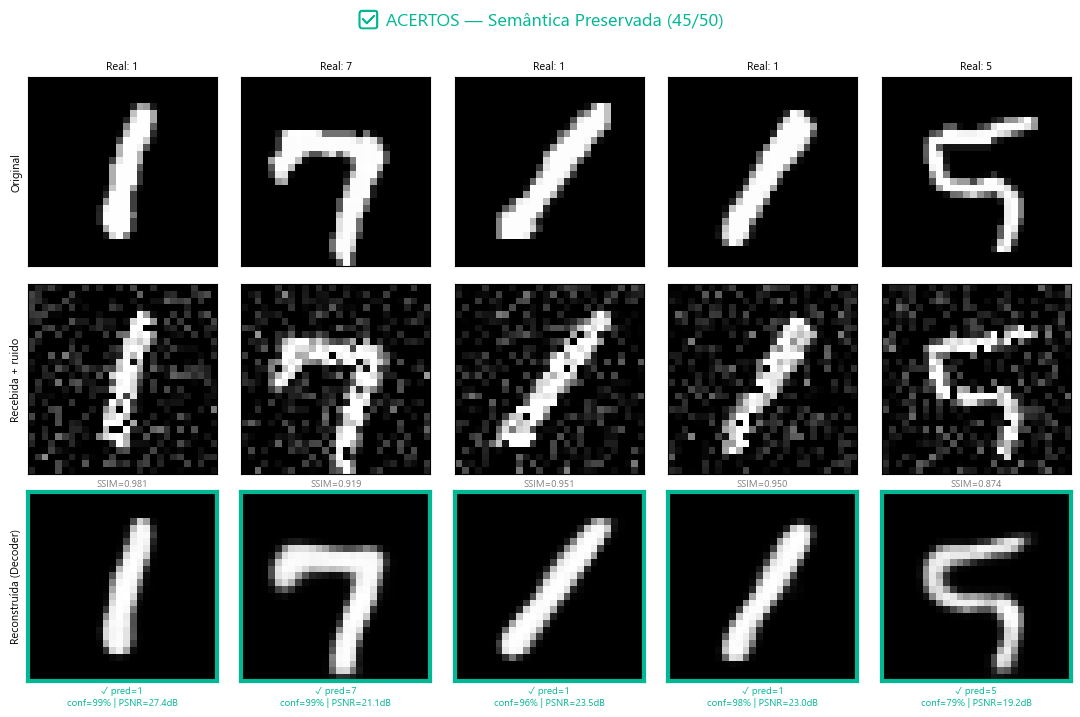

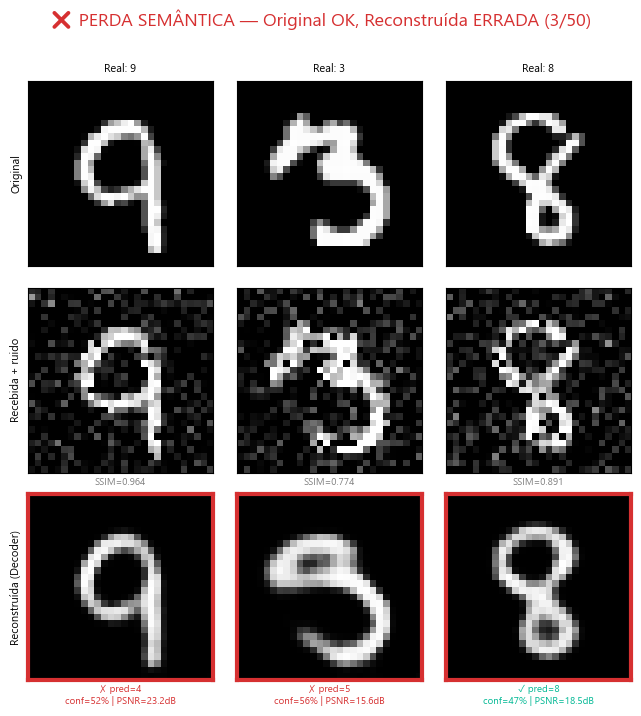

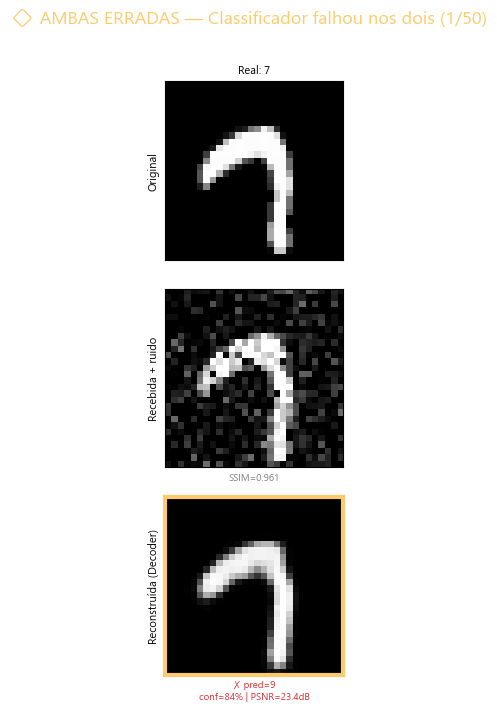

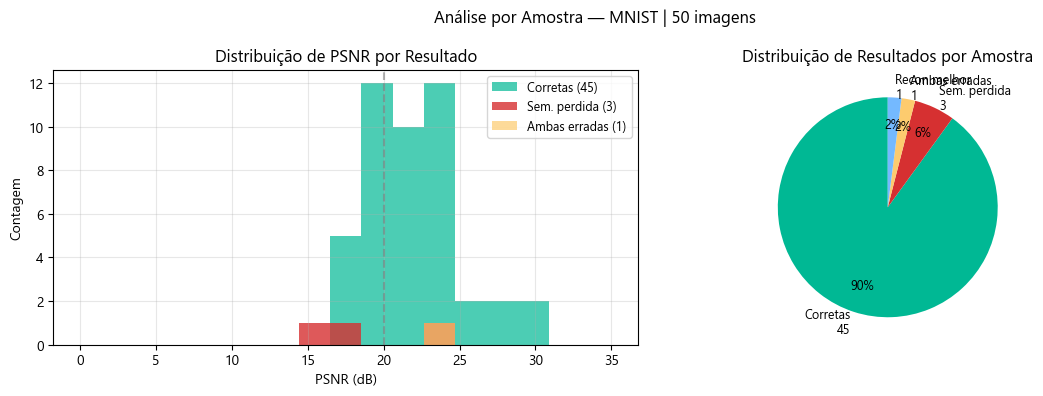


  PSNR médio por categoria:
  ✅ Corretas       : 21.90 dB (min=17.3 max=29.3)
  ❌ Sem. perdida   : 19.09 dB (min=15.6 max=23.2)
  🔶 Ambas erradas  : 23.44 dB

  Insight: imagens com PSNR < ~21.9 dB tendem a perder a semantica.
  Aumente SNR ou reduza masking para melhorar a qualidade de reconstrucao.


In [ ]:
# Célula 6 — Galeria Visual: Acertos e Erros do Classificador
#
# Chama o benchmark com 30 amostras e include_samples=True para obter:
#   - As imagens original, recebida e reconstruída de cada amostra
#   - O resultado do classificador em cada uma (correto/errado)
#
# O grid mostra 4 seções:
#   ✅ ACERTOS (reconstruída classificada corretamente)
#   ❌ ERROS   (semântica perdida — original ok mas reconstruída errada)
#   🔶 AMBAS ERRADAS (original e reconstruída erradas)
#   📊 Histograma de PSNR colorido por resultado

import json, requests
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
plt.rcParams['font.family'] = 'Segoe UI Emoji' # Fonte padrão de emojis do Windows

ML_SERVICE = 'http://localhost:8000'

try:
    ref = json.loads(Path('shared_data/resultados/notebook_monitor/treino_ref.json').read_text())
    DS = ref.get('dataset', 'mnist'); MD = ref.get('model', 'cnn_vae')
except:
    DS = 'mnist'; MD = 'cnn_vae'

# ── Configurações visuais ──────────────────────────────────────────────────
N_AMOSTRAS  = 30   # total de imagens avaliadas
N_MOSTRAR   = 6    # quantas mostrar em cada categoria
DS_LABELS   = {    # nomes das classes por dataset
    'mnist':   [str(i) for i in range(10)],
    'fashion': ['Camiseta','Calca','Pullover','Vestido','Casaco',
                'Sandalia','Camisa','Tenis','Bolsa','Bota'],
    'cifar10': ['Aviao','Carro','Passaro','Gato','Cervo',
                'Cachorro','Sapo','Cavalo','Barco','Caminhao'],
}
LABEL_NAMES = DS_LABELS.get(DS, [str(i) for i in range(10)])

COR_OK    = '#00b894'   # verde — acerto
COR_ERROU = '#d63031'   # vermelho — perdeu semântica
COR_AMBAS = '#fdcb6e'   # amarelo — ambas erradas

print(f'[galeria] Buscando {N_AMOSTRAS} amostras com imagens de {DS.upper()}...')

resp = requests.post(f'{ML_SERVICE}/experiment/benchmark', json={
    'datasets': [DS], 'models': [MD], 'bits': 8,
    'num_samples': N_AMOSTRAS, 'seed': 99,
    'awgn':    {'enabled': True, 'snr_db': 15},
    'masking': {'enabled': True, 'drop_rate': 0.1, 'fill_value': 0.0},
    'classifier': {'enabled': True, 'min_confidence': 0.5, 'top_k': 1},
    'include_samples': True,   # ← retorna imagens + resultado por amostra
}, timeout=300)

if resp.status_code != 200:
    print(f'Erro: {resp.status_code} {resp.text[:300]}')
else:
    res = resp.json()
    resultado = res.get('results', [{}])[0] if res.get('results') else {}
    cls  = resultado.get('classification', {})
    amostras = cls.get('samples', [])

    if not amostras:
        print('[galeria] Nenhuma amostra retornada. Verifique se a celula 4.5 foi executada.')
    else:
        # ── Separar por categoria ──────────────────────────────────────────
        acertos      = [s for s in amostras if s.get('orig_ok') and s.get('recon_ok')]
        perdeu_semat = [s for s in amostras if s.get('orig_ok') and not s.get('recon_ok')]
        ambas_erradas= [s for s in amostras if not s.get('orig_ok') and not s.get('recon_ok')]
        orig_errada  = [s for s in amostras if not s.get('orig_ok') and s.get('recon_ok')]

        total = len(amostras)
        print(f'
  Classificação em {total} amostras:')
        print(f'  ✅ Ambas corretas       : {len(acertos):>3} ({len(acertos)/total*100:.1f}%)')
        print(f'  ❌ Semântica perdida    : {len(perdeu_semat):>3} ({len(perdeu_semat)/total*100:.1f}%)  ← orig ok, recon errada')
        print(f'  🔶 Ambas erradas        : {len(ambas_erradas):>3} ({len(ambas_erradas)/total*100:.1f}%)')
        print(f'  🔷 Recon melhor q orig  : {len(orig_errada):>3} ({len(orig_errada)/total*100:.1f}%)')

        def _img(arr_data):
            arr = np.array(arr_data)
            if arr.ndim == 3 and arr.shape[0] in (1, 3):
                arr = np.transpose(arr, (1, 2, 0)).squeeze()
            return np.clip(arr, 0, 1)

        def _nome(label_idx):
            try: return LABEL_NAMES[int(label_idx)]
            except: return str(label_idx)

        def _pred_nome(pred_idx):
            try: return LABEL_NAMES[int(pred_idx)]
            except: return str(pred_idx)

        # ── FUNÇÃO: desenhar grade de amostras ─────────────────────────────
        def _grade(samples, titulo_secao, cor_borda, max_itens=N_MOSTRAR):
            items = samples[:max_itens]
            if not items:
                return
            ncols = len(items)
            fig, axes = plt.subplots(3, ncols, figsize=(ncols * 2.2, 7))
            if ncols == 1:
                axes = axes.reshape(3, 1)

            fig.suptitle(titulo_secao, fontsize=13, fontweight='bold', color=cor_borda, y=1.01)
            linhas = ['Original', 'Recebida + ruido', 'Reconstruída (Decoder)']
            chaves = ['original_img', 'received_img', 'reconstructed_img']
            campos = ['original', 'received', 'reconstructed']

            for col, s in enumerate(items):
                real  = _nome(s['label'])
                psnr  = s.get('psnr', 0)
                ssim  = s.get('ssim', 0)

                for row, (chave, campo, linha) in enumerate(zip(chaves, campos, linhas)):
                    ax = axes[row][col]
                    img_data = s.get(chave)
                    if img_data is not None:
                        arr = _img(img_data)
                        ax.imshow(arr, cmap='gray' if arr.ndim == 2 else None)
                    else:
                        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)

                    # Borda colorida na imagem reconstruída
                    if row == 2:
                        for spine in ax.spines.values():
                            spine.set_edgecolor(cor_borda)
                            spine.set_linewidth(3)

                    # Título das colunas (apenas linha 0)
                    if row == 0:
                        pred_orig = s.get('original', {})
                        cor_t = COR_OK if pred_orig.get('correct_top1') else COR_ERROU
                        ax.set_title(f'Real: {real}', fontsize=8, color='black')

                    # Info da classificação nareconstruída (linha 2)
                    if row == 2:
                        pred_r = s.get('reconstructed', {})
                        pred_nome = _pred_nome(pred_r.get('pred', '?'))
                        conf = pred_r.get('confidence', 0)
                        ok_r = pred_r.get('correct_top1', False)
                        cor_label = COR_OK if ok_r else COR_ERROU
                        ax.set_xlabel(
                            f'{"✓" if ok_r else "✗"} pred={pred_nome}
conf={conf:.0%} | PSNR={psnr:.1f}dB',
                            fontsize=7, color=cor_label
                        )
                    else:
                        if row == 1:
                            ax.set_xlabel(f'SSIM={ssim:.3f}', fontsize=7, color='gray')

                    ax.set_xticks([]); ax.set_yticks([])
                    if col == 0:
                        ax.set_ylabel(linha, fontsize=8)

            plt.tight_layout()
            fname = titulo_secao[:30].strip().lower().replace(' ', '_').replace(':', '').replace('❌','erro').replace('✅','ok').replace('🔶','ambas')
            plt.savefig(f'shared_data/resultados/notebook_monitor/galeria_{fname}.png',
                        dpi=110, bbox_inches='tight')
            plt.show()

        # ── Renderizar grades ──────────────────────────────────────────────
        _grade(acertos,
               f'✅ ACERTOS — Semântica Preservada ({len(acertos)}/{total})',
               COR_OK)

        if perdeu_semat:
            _grade(perdeu_semat,
                   f'❌ PERDA SEMÂNTICA — Original OK, Reconstruída ERRADA ({len(perdeu_semat)}/{total})',
                   COR_ERROU)

        if ambas_erradas:
            _grade(ambas_erradas,
                   f'🔶 AMBAS ERRADAS — Classificador falhou nos dois ({len(ambas_erradas)}/{total})',
                   COR_AMBAS)

        # ── Histograma de PSNR por categoria ──────────────────────────────
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f'Análise por Amostra — {DS.upper()} | {total} imagens', fontsize=12, fontweight='bold')

        # PSNR por categoria
        psnrs_ok    = [s['psnr'] for s in acertos]
        psnrs_erro  = [s['psnr'] for s in perdeu_semat]
        psnrs_ambas = [s['psnr'] for s in ambas_erradas]
        bins = np.linspace(0, 35, 18)
        if psnrs_ok:    ax1.hist(psnrs_ok,    bins=bins, alpha=0.7, color=COR_OK,    label=f'Corretas ({len(psnrs_ok)})')
        if psnrs_erro:  ax1.hist(psnrs_erro,  bins=bins, alpha=0.8, color=COR_ERROU, label=f'Sem. perdida ({len(psnrs_erro)})')
        if psnrs_ambas: ax1.hist(psnrs_ambas, bins=bins, alpha=0.7, color=COR_AMBAS, label=f'Ambas erradas ({len(psnrs_ambas)})')
        ax1.set_xlabel('PSNR (dB)'); ax1.set_ylabel('Contagem')
        ax1.set_title('Distribuição de PSNR por Resultado'); ax1.legend(fontsize=9)
        ax1.axvline(x=20, color='gray', linestyle='--', alpha=0.6, label='PSNR=20dB')
        ax1.grid(alpha=0.3)

        # Pizza de categorias
        categorias = []
        valores    = []
        cores      = []
        if acertos:       categorias.append(f'Corretas
{len(acertos)}'); valores.append(len(acertos)); cores.append(COR_OK)
        if perdeu_semat:  categorias.append(f'Sem. perdida
{len(perdeu_semat)}'); valores.append(len(perdeu_semat)); cores.append(COR_ERROU)
        if ambas_erradas: categorias.append(f'Ambas erradas
{len(ambas_erradas)}'); valores.append(len(ambas_erradas)); cores.append(COR_AMBAS)
        if orig_errada:   categorias.append(f'Recon melhor
{len(orig_errada)}'); valores.append(len(orig_errada)); cores.append('#74b9ff')
        wedges, texts, autotexts = ax2.pie(
            valores, labels=categorias, colors=cores,
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 9}, pctdistance=0.75
        )
        for at in autotexts: at.set_fontweight('bold')
        ax2.set_title('Distribuição de Resultados por Amostra')

        plt.tight_layout()
        plt.savefig('shared_data/resultados/notebook_monitor/galeria_analise.png', dpi=120, bbox_inches='tight')
        plt.show()

        # ── Estatísticas de PSNR por categoria ────────────────────────────
        print()
        print('  PSNR médio por categoria:')
        if psnrs_ok:    print(f'  ✅ Corretas       : {np.mean(psnrs_ok):.2f} dB (min={np.min(psnrs_ok):.1f} max={np.max(psnrs_ok):.1f})')
        if psnrs_erro:  print(f'  ❌ Sem. perdida   : {np.mean(psnrs_erro):.2f} dB (min={np.min(psnrs_erro):.1f} max={np.max(psnrs_erro):.1f})')
        if psnrs_ambas: print(f'  🔶 Ambas erradas  : {np.mean(psnrs_ambas):.2f} dB')
        if psnrs_erro:
            limiar = np.mean(psnrs_ok) if psnrs_ok else 0
            print()
            print(f'  Insight: imagens com PSNR < ~{limiar:.1f} dB tendem a perder a semantica.')
            print(f'  Aumente SNR ou reduza masking para melhorar a qualidade de reconstrucao.')

---
## 🏭 Módulo 4: A Fábrica de Trabalhos (Triple Trade-off)

O Evento Principal. Estressando as taxas de compactação a níveis drásticos para exportar pontuações de Acurácia x Compressão para o Manuscripto Final acadêmico.


In [4]:
# Célula 7 — Análise de Trade-off (Acurácia vs. Compressão)
#
# Este script varre automaticamente diferentes tamanhos do Espaço Latente (latent_dim)
# para encontrar a "Curva de Otimização" entre compressão e manutenção da semântica.
#
# IMPORTANTE: Recomenda-se rodar isso com CIFAR-10 ou Fashion-MNIST

import requests
import time
import matplotlib.pyplot as plt

ML_SERVICE = 'http://localhost:8000'
DIMENSOES_TESTE = [16, 32, 64, 128]

resultados_tradeoff = {}

print(f"=== INICIANDO TRADE-OFF PARA O DATASET {DATASET.upper()} ===")

for dim in DIMENSOES_TESTE:
    print(f"\n[{dim} bytes] 1/3 - Iniciando FedAvg...")
    req_train = requests.post(f'{ML_SERVICE}/training/start', json={
        'dataset': DATASET, 'model': MODEL, 'latent_dim': dim,
        'clients': 2, 'epochs': EPOCHS, 'rounds': ROUNDS,
        'awgn': AWGN_CFG,
        'masking': MASK_CFG
    })
    
    if req_train.status_code != 200:
        print(f"Erro no treino: {req_train.text}")
        continue
        
    while True:
        status = requests.get(f'{ML_SERVICE}/training/status').json()
        if not status.get('running'): break
        time.sleep(5)
        
    print(f"[{dim} bytes] 2/3 - Ajustando Classificador...")
    req_clf = requests.post(f'{ML_SERVICE}/classifier/train', json={
        'dataset': DATASET, 'epochs': 5, 'batch': 128, 'latent_dim': dim,
        'semantic_model': MODEL, 'semantic_weights': 'latest'
    })
    
    while True:
        status = requests.get(f'{ML_SERVICE}/classifier/status').json()
        if status.get('done') or not status.get('running'): break
        time.sleep(5)
        
    print(f"[{dim} bytes] 3/3 - Executando Benchmark do Canal Semântico...")
    req_bench = requests.post(f'{ML_SERVICE}/experiment/benchmark', json={
        'datasets': [DATASET], 'models': [MODEL], 'latent_dim': dim,
        'num_samples': 50,
        'awgn': AWGN_CFG,
        'masking': MASK_CFG,
        'classifier': {'enabled': True}
    })
    
    dados = req_bench.json()['results'][0]
    
    ssim = dados['ssim_mean']
    acc_orig = dados['classification']['accuracy_original']
    acc_recon = dados['classification']['accuracy_reconstructed']
    queda = acc_orig - acc_recon
    comp_ratio = dados['compression_ratio_mean']
    
    resultados_tradeoff[dim] = {
        'ssim': ssim, 'queda': queda, 'comp_ratio': comp_ratio
    }
    print(f"  => Compressão: {comp_ratio:.1f}x | SSIM: {ssim:.3f} | Queda Semântica: {queda*100:.1f}%")

# Plotando os Gráficos de Trade-off
dims = list(resultados_tradeoff.keys())
quedas = [resultados_tradeoff[d]['queda']*100 for d in dims]
compressoes = [resultados_tradeoff[d]['comp_ratio'] for d in dims]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(dims, compressoes, 'b-o', linewidth=2, label='Fator de Compressão (x)')
ax2.plot(dims, quedas, 'r-s', linewidth=2, label='Queda Semântica (%)')

ax1.set_xlabel('Dimensão Latente (Bytes Transmitidos)')
ax1.set_ylabel('Compressão (Vezes)', color='b')
ax2.set_ylabel('Queda na Acurácia (%)', color='r')

# Linhas de referência úteis:
ax2.axhline(10, color='r', linestyle=':', label='Limite de Tolerância (10%)')

ax1.grid(True, linestyle='--', alpha=0.6)
plt.title(f'Trade-off: Compressão vs Queda Semântica no VAE Federado ({DATASET.upper()})')
fig.tight_layout()
plt.savefig(f'shared_data/resultados/notebook_monitor/tradeoff_plot_{DATASET}.png')
plt.show()

print(f"\n=== TESTES CONCLUIDOS. GRAFICO SALVO. ===")


=== INICIANDO TRADE-OFF PARA O DATASET CIFAR10 ===

[16 bytes] 1/3 - Iniciando FedAvg...


KeyboardInterrupt: 